In [1]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

stocks_names = ['reliance', 'tcs', 'infosys', 'hdfc_bank', 'wipro']
clean_data = {}

for name in stocks_names:
    df = pd.read_csv(f'../data/cleaned/{name}_clean.csv', index_col=0, parse_dates=True)
    clean_data[name] = df

print("Data loaded for dashboard! ✅")

Data loaded for dashboard! ✅


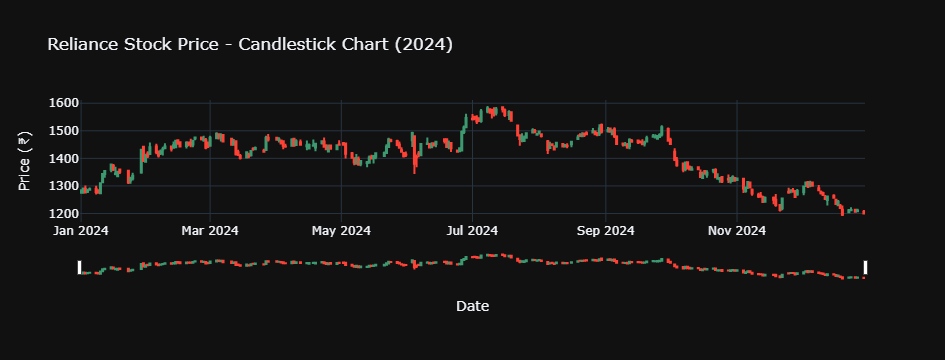

In [3]:
df = clean_data['reliance']

fig = go.Figure(data=[go.Candlestick(
    x=df.index,
    open=df['Open'],
    high=df['High'],
    low=df['Low'],
    close=df['Close'],
    name='Reliance'
)])

fig.update_layout(
    title='Reliance Stock Price - Candlestick Chart (2024)',
    xaxis_title='Date',
    yaxis_title='Price (₹)',
    xaxis_rangeslider_visible=True,
    template='plotly_dark'
)

fig.write_html('../visuals/reliance_candlestick.html')
fig.show()

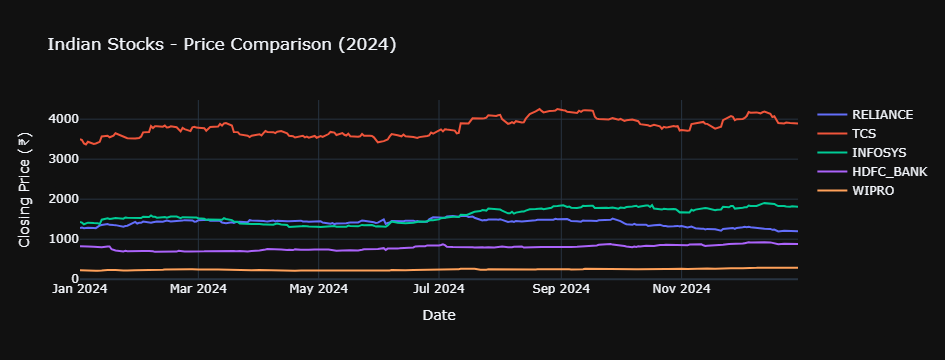

In [4]:
fig = go.Figure()

for name, df in clean_data.items():
    fig.add_trace(go.Scatter(
        x=df.index,
        y=df['Close'],
        mode='lines',
        name=name.upper()
    ))

fig.update_layout(
    title='Indian Stocks - Price Comparison (2024)',
    xaxis_title='Date',
    yaxis_title='Closing Price (₹)',
    template='plotly_dark',
    hovermode='x unified'
)

fig.write_html('../visuals/all_stocks_comparison.html')
fig.show()

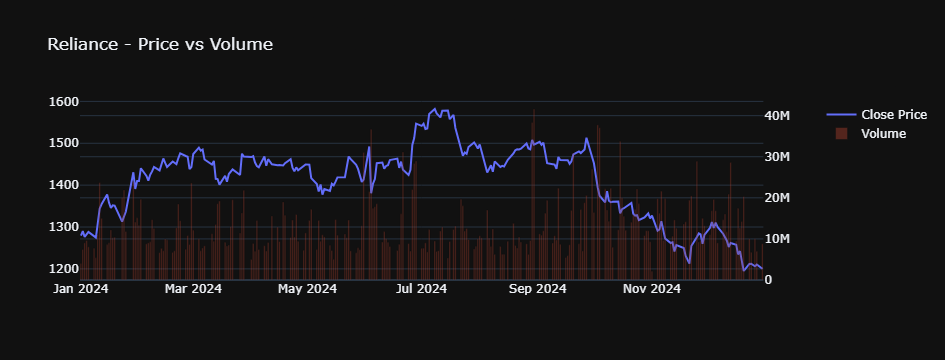

In [5]:
df = clean_data['reliance']

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(go.Scatter(x=df.index, y=df['Close'], name='Close Price'), secondary_y=False)
fig.add_trace(go.Bar(x=df.index, y=df['Volume'], name='Volume', opacity=0.3), secondary_y=True)

fig.update_layout(
    title='Reliance - Price vs Volume',
    template='plotly_dark'
)

fig.write_html('../visuals/reliance_price_volume.html')
fig.show()